# Week 4 — Baseline & First Model
**Project:** Drug Side Effect Predictor  
**Goal:** Build a frequency baseline to establish a performance floor, then train two multi-label classifiers (Logistic Regression and Linear SVM) and compare all three on a standardised metrics table.

**Inputs (from Week 3):**
- `data/processed/X_train.npz` — sparse feature matrix (893 drugs × ~300 features)
- `data/processed/X_test.npz`  — sparse feature matrix (224 drugs × ~300 features)
- `data/processed/y_train.npy` — label matrix (893 × 845)
- `data/processed/y_test.npy`  — label matrix (224 × 845)
- `data/processed/label_names.csv` — ordered list of 845 side effect names
- `data/processed/train_index.csv` / `test_index.csv` — drug ID + name lookup

**Decisions to make this week:**
- K — the fixed prediction budget per drug (set from training-set median in Step 4.1)
- Which model (LR or SVM) advances to Week 5 tuning (set by the modeling checkpoint)

**Metric definitions:**
- **micro-F1** — primary metric; weights each label by support; punishes missing common side effects
- **macro-F1** — unweighted average per label; reveals performance on rare side effects
- **precision@K** — of the K side effects predicted per drug, what fraction are correct?
- **recall@K** — of all actual side effects, what fraction fall within the top-K predictions?

## Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import sparse
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
import joblib
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# Paths
PROCESSED = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\data\processed\\"
MODELS    = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\models\\"
FIGURES   = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\figures\\"

for folder in [MODELS, FIGURES]:
    os.makedirs(folder, exist_ok=True)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


## Load data

In [3]:
X_train = sparse.load_npz(PROCESSED + 'X_train.npz')
X_test  = sparse.load_npz(PROCESSED + 'X_test.npz')

y_train = np.load(PROCESSED + 'y_train.npy')
y_test  = np.load(PROCESSED + 'y_test.npy')

label_names = pd.read_csv(PROCESSED + 'label_names.csv')['side_effect'].tolist()

train_index = pd.read_csv(PROCESSED + 'train_index.csv')
test_index  = pd.read_csv(PROCESSED + 'test_index.csv')

print(f'X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}    y_test:  {y_test.shape}')
print(f'Labels:  {len(label_names)}')
print(f'Train drugs: {len(train_index)}   Test drugs: {len(test_index)}')

X_train: (893, 282)   y_train: (893, 845)
X_test:  (224, 282)    y_test:  (224, 845)
Labels:  845
Train drugs: 893   Test drugs: 224


---
## Step 4.1 — Choose K (prediction budget)

Every model will predict **exactly K side effects per drug**. This makes precision@K and recall@K directly comparable across all approaches.

K is set to the **median number of side effects per drug in the training set**. We never look at `y_test` for this decision.

In [4]:
train_label_counts = y_train.sum(axis=1)

K = int(np.median(train_label_counts))

print('Training label cardinality:')
print(f'  Median : {K}   <- this becomes K')
print(f'  Mean   : {train_label_counts.mean():.1f}')
print(f'  Min    : {int(train_label_counts.min())}')
print(f'  Max    : {int(train_label_counts.max())}')
print()
print(f'K = {K}  (every model will predict exactly {K} side effects per drug)')

Training label cardinality:
  Median : 68   <- this becomes K
  Mean   : 95.1
  Min    : 1
  Max    : 550

K = 68  (every model will predict exactly 68 side effects per drug)


---
## Step 4.2 — Frequency baseline

The simplest possible predictor: **always predict the K most frequent side effects in the training set**, regardless of the drug.

This baseline never looks at X. It captures how much performance can be explained by label frequency alone. Any useful model must beat it.

**How it works:**
1. Rank all 845 side effects by their total count in `y_train`
2. Take the top-K — this is the single fixed prediction set
3. Repeat that set for every test drug
4. Compute metrics against `y_test`

In [5]:
def precision_at_k(y_true, y_pred_binary):
    hits = (y_true * y_pred_binary).sum(axis=1)
    k_per_drug = y_pred_binary.sum(axis=1)
    per_drug = np.where(k_per_drug > 0, hits / k_per_drug, 0.0)
    return per_drug.mean()


def recall_at_k(y_true, y_pred_binary):
    hits = (y_true * y_pred_binary).sum(axis=1)
    actual_count = y_true.sum(axis=1)
    mask = actual_count > 0
    return (hits[mask] / actual_count[mask]).mean()


def compute_metrics(y_true, y_pred_binary, label=''):
    micro_f1 = f1_score(y_true, y_pred_binary, average='micro', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred_binary, average='macro', zero_division=0)
    prec_k   = precision_at_k(y_true, y_pred_binary)
    rec_k    = recall_at_k(y_true, y_pred_binary)

    print(f'{chr(8212)*45}')
    print(f'  {label}')
    print(f'{chr(8212)*45}')
    print(f'  micro-F1      : {micro_f1:.4f}')
    print(f'  macro-F1      : {macro_f1:.4f}')
    print(f'  precision@{K:<4}: {prec_k:.4f}')
    print(f'  recall@{K:<6}: {rec_k:.4f}')
    print()

    return {
        'model'              : label,
        'micro_F1'           : round(micro_f1, 4),
        'macro_F1'           : round(macro_f1, 4),
        f'precision@K'       : round(prec_k, 4),
        f'recall@K'          : round(rec_k, 4),
    }


print('Helper functions defined.')

Helper functions defined.


In [6]:
# Rank labels by training frequency
label_freq    = y_train.sum(axis=0)
top_k_indices = np.argsort(label_freq)[::-1][:K]

print(f'Top-{K} most frequent side effects (by training count):')
for i, idx in enumerate(top_k_indices[:10], 1):
    print(f'  {i:>2}. {label_names[idx]:<45} ({int(label_freq[idx])} drugs)')
print(f'  ... ({K - 10} more)')
print()

n_test = y_test.shape[0]
y_pred_baseline = np.zeros((n_test, y_test.shape[1]), dtype=np.int8)
y_pred_baseline[:, top_k_indices] = 1

print(f'Baseline prediction matrix shape: {y_pred_baseline.shape}')
print(f'Predicted labels per drug:        {y_pred_baseline.sum(axis=1).mean():.0f}  (should be {K})')

Top-68 most frequent side effects (by training count):
   1. Nausea                                        (777 drugs)
   2. Headache                                      (728 drugs)
   3. Vomiting                                      (705 drugs)
   4. Dermatitis                                    (696 drugs)
   5. Rash                                          (691 drugs)
   6. Dizziness                                     (678 drugs)
   7. Diarrhoea                                     (633 drugs)
   8. Pruritus                                      (611 drugs)
   9. Asthenia                                      (597 drugs)
  10. Hypersensitivity                              (593 drugs)
  ... (58 more)

Baseline prediction matrix shape: (224, 845)
Predicted labels per drug:        68  (should be 68)


In [7]:
baseline_metrics = compute_metrics(y_test, y_pred_baseline, label='Frequency Baseline')

—————————————————————————————————————————————
  Frequency Baseline
—————————————————————————————————————————————
  micro-F1      : 0.3987
  macro-F1      : 0.0545
  precision@68  : 0.5221
  recall@68    : 0.4020



---
## Step 4.3 — OneVsRest + Logistic Regression

`OneVsRestClassifier` trains one binary classifier per label (845 classifiers total).

**Why Logistic Regression first?**
- Produces calibrated probabilities via `predict_proba` — essential for ranking top-K
- Fast on sparse data; regularisation (C) is easy to tune
- Coefficients are interpretable

**Settings:**
- `solver='saga'` — fastest solver for sparse, high-dimensional data
- `C=1.0` — default regularisation strength (tuned in Week 5)
- `max_iter=1000` — generous to ensure convergence
- `class_weight='balanced'` — compensates for low label density (~11.6%)
- `n_jobs=-1` — parallelise across all CPU cores

**Top-K selection:** Take `predict_proba` scores, pick the K highest per drug.

In [8]:
print('Training OneVsRest + Logistic Regression ...')
print('(Fits 845 binary classifiers — may take 1-3 minutes)\n')

lr_base = LogisticRegression(
    solver='saga',
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

lr_model = OneVsRestClassifier(lr_base, n_jobs=-1)
lr_model.fit(X_train, y_train)

print('Training complete.')

Training OneVsRest + Logistic Regression ...
(Fits 845 binary classifiers — may take 1-3 minutes)

Training complete.


In [9]:
lr_scores = lr_model.predict_proba(X_test)

y_pred_lr = np.zeros_like(lr_scores, dtype=np.int8)
top_k_lr  = np.argsort(lr_scores, axis=1)[:, -K:]
for i, cols in enumerate(top_k_lr):
    y_pred_lr[i, cols] = 1

print(f'LR prediction matrix shape: {y_pred_lr.shape}')
print(f'Predicted labels per drug:  {y_pred_lr.sum(axis=1).mean():.0f}  (should be {K})')
print()

lr_metrics = compute_metrics(y_test, y_pred_lr, label='OneVsRest + Logistic Regression (C=1.0)')

joblib.dump(lr_model, MODELS + 'lr_model.pkl')
print('Model saved: models/lr_model.pkl')

LR prediction matrix shape: (224, 845)
Predicted labels per drug:  68  (should be 68)

—————————————————————————————————————————————
  OneVsRest + Logistic Regression (C=1.0)
—————————————————————————————————————————————
  micro-F1      : 0.2761
  macro-F1      : 0.2112
  precision@68  : 0.3615
  recall@68    : 0.3082

Model saved: models/lr_model.pkl


---
## Step 4.4 — OneVsRest + Linear SVM

**Why Linear SVM second?**
- Often outperforms LR on sparse, high-dimensional text/categorical features
- Maximises the margin — better separation on linearly separable problems
- Faster training than kernel SVMs

**Settings:**
- `C=1.0` — default; tuned in Week 5
- `max_iter=2000` — LinearSVC can need more iterations than LR on sparse data
- `class_weight='balanced'` — same rationale as LR
- `dual='auto'` — lets sklearn pick primal/dual based on problem shape

**Top-K selection:** Use `decision_function` scores (signed distance to hyperplane), pick the K highest per drug.

In [10]:
print('Training OneVsRest + Linear SVM ...')
print('(Fits 845 binary classifiers — may take 2-5 minutes)\n')

svm_base = LinearSVC(
    C=1.0,
    max_iter=2000,
    class_weight='balanced',
    dual='auto',
    random_state=42,
)

svm_model = OneVsRestClassifier(svm_base, n_jobs=-1)
svm_model.fit(X_train, y_train)

print('Training complete.')

Training OneVsRest + Linear SVM ...
(Fits 845 binary classifiers — may take 2-5 minutes)

Training complete.


In [11]:
svm_scores = svm_model.decision_function(X_test)

y_pred_svm = np.zeros_like(svm_scores, dtype=np.int8)
top_k_svm  = np.argsort(svm_scores, axis=1)[:, -K:]
for i, cols in enumerate(top_k_svm):
    y_pred_svm[i, cols] = 1

print(f'SVM prediction matrix shape: {y_pred_svm.shape}')
print(f'Predicted labels per drug:   {y_pred_svm.sum(axis=1).mean():.0f}  (should be {K})')
print()

svm_metrics = compute_metrics(y_test, y_pred_svm, label='OneVsRest + Linear SVM (C=1.0)')

joblib.dump(svm_model, MODELS + 'svm_model.pkl')
print('Model saved: models/svm_model.pkl')

SVM prediction matrix shape: (224, 845)
Predicted labels per drug:   68  (should be 68)

—————————————————————————————————————————————
  OneVsRest + Linear SVM (C=1.0)
—————————————————————————————————————————————
  micro-F1      : 0.3090
  macro-F1      : 0.2090
  precision@68  : 0.4047
  recall@68    : 0.3276

Model saved: models/svm_model.pkl


---
## Step 4.5 — Comparison table

All three approaches evaluated on the same test set, with the same K and the same metrics. The **micro-F1 column** determines which model advances to Week 5 tuning.

In [12]:
results = pd.DataFrame([baseline_metrics, lr_metrics, svm_metrics])
results = results.set_index('model')

print('=' * 80)
print(f'  WEEK 4 — MODEL COMPARISON  (K = {K})')
print('=' * 80)
print(results.to_string())
print()

best_model  = results['micro_F1'].idxmax()
baseline_f1 = results.loc['Frequency Baseline', 'micro_F1']
best_f1     = results.loc[best_model, 'micro_F1']
improvement = best_f1 - baseline_f1

print(f'Best model by micro-F1 : {best_model}')
print(f'  Baseline micro-F1   : {baseline_f1:.4f}')
print(f'  Best micro-F1       : {best_f1:.4f}')
print(f'  Improvement         : {improvement:+.4f}')

results.to_csv(MODELS + 'week4_comparison.csv')
print('\nTable saved: models/week4_comparison.csv')

  WEEK 4 — MODEL COMPARISON  (K = 68)
                                         micro_F1  macro_F1  precision@K  recall@K
model                                                                             
Frequency Baseline                         0.3987    0.0545       0.5221    0.4020
OneVsRest + Logistic Regression (C=1.0)    0.2761    0.2112       0.3615    0.3082
OneVsRest + Linear SVM (C=1.0)             0.3090    0.2090       0.4047    0.3276

Best model by micro-F1 : Frequency Baseline
  Baseline micro-F1   : 0.3987
  Best micro-F1       : 0.3987
  Improvement         : +0.0000

Table saved: models/week4_comparison.csv


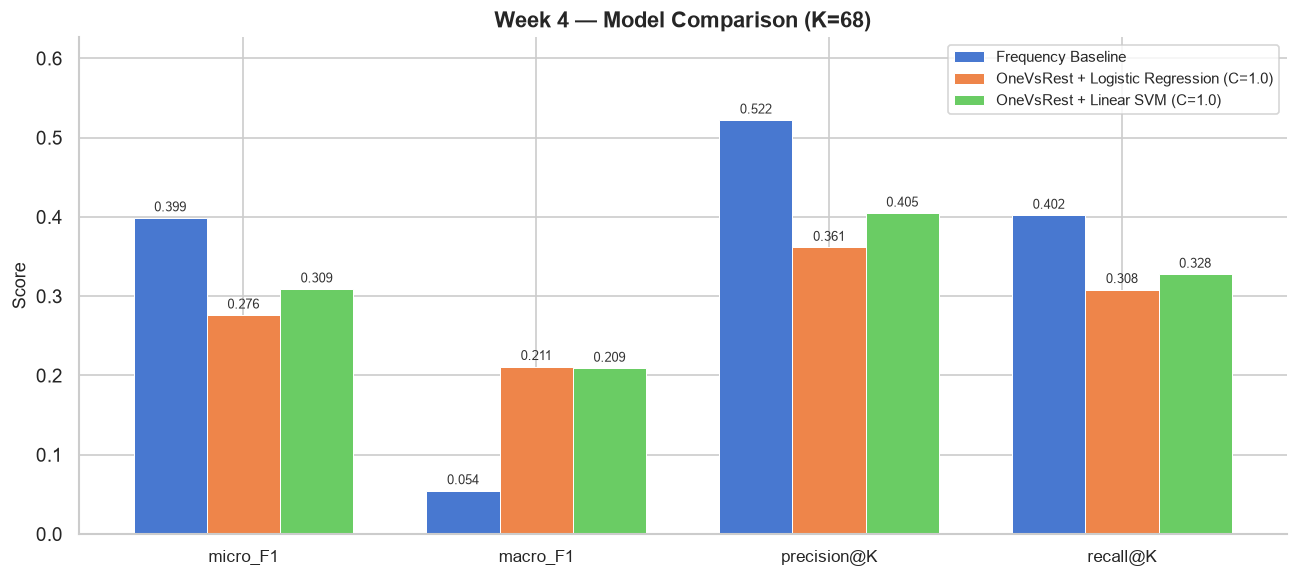

Saved: figures/4.5_model_comparison.png


In [13]:
metric_cols = list(results.columns)
x           = np.arange(len(metric_cols))
width       = 0.25
palette     = sns.color_palette('muted', 3)

fig, ax = plt.subplots(figsize=(11, 5))

for i, (model_name, row) in enumerate(results.iterrows()):
    offset = (i - 1) * width
    bars   = ax.bar(
        x + offset,
        row[metric_cols].values,
        width,
        label=model_name,
        color=palette[i],
        edgecolor='white',
        linewidth=0.6,
    )
    for bar, val in zip(bars, row[metric_cols].values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=7.5, color='#333'
        )

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, min(1.0, results.values.max() * 1.2))
ax.set_title(f'Week 4 — Model Comparison (K={K})', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
sns.despine()

plt.tight_layout()
plt.savefig(FIGURES + '4.5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/4.5_model_comparison.png')

---
## Modeling Checkpoint

Decision rule:

> *If the better model shows measurable improvement over the frequency baseline on micro-F1 → proceed to Week 5 tuning and then Streamlit.*  
> *If not → Week 5 focuses on diagnosing why and improving the pipeline; the Streamlit app is deferred.*

In [14]:
IMPROVEMENT_THRESHOLD = 0.01  # 1 percentage point above baseline is "measurable"

print('=' * 60)
print('  MODELING CHECKPOINT')
print('=' * 60)
print(f'  Baseline micro-F1         : {baseline_f1:.4f}')
print(f'  Best model micro-F1       : {best_f1:.4f}  ({best_model})')
print(f'  Improvement over baseline : {improvement:+.4f}')
print()

if improvement >= IMPROVEMENT_THRESHOLD:
    print('  PASS — Model beats the baseline.')
    print(f'  -> Week 5: Tune {best_model} with cross-validation.')
    print('  -> Streamlit app: ON track.')
    checkpoint = 'PASS'
else:
    print('  FLAG — Model does not clearly beat the baseline.')
    print('  -> Week 5: Diagnose the pipeline (feature sparsity, K value,')
    print('     label threshold). Polish notebook; defer Streamlit.')
    checkpoint = 'FLAG'

print()
print(f'  Checkpoint decision: {checkpoint}')
print('=' * 60)

checkpoint_summary = {
    'K'                 : K,
    'baseline_micro_f1' : round(baseline_f1, 4),
    'best_model'        : best_model,
    'best_micro_f1'     : round(best_f1, 4),
    'improvement'       : round(improvement, 4),
    'checkpoint'        : checkpoint,
}
pd.Series(checkpoint_summary).to_csv(MODELS + 'week4_checkpoint.csv', header=['value'])
print('\nCheckpoint saved: models/week4_checkpoint.csv')

  MODELING CHECKPOINT
  Baseline micro-F1         : 0.3987
  Best model micro-F1       : 0.3987  (Frequency Baseline)
  Improvement over baseline : +0.0000

  FLAG — Model does not clearly beat the baseline.
  -> Week 5: Diagnose the pipeline (feature sparsity, K value,
     label threshold). Polish notebook; defer Streamlit.

  Checkpoint decision: FLAG

Checkpoint saved: models/week4_checkpoint.csv


---
## Week 4 Summary

| Step | What was done | Output |
|---|---|---|
| 4.1 | Determined K from training-set median label cardinality | K (printed above) |
| 4.2 | Frequency baseline — top-K most common labels for every drug | `y_pred_baseline` |
| 4.3 | OneVsRest + Logistic Regression (C=1.0, saga, balanced) | `models/lr_model.pkl` |
| 4.4 | OneVsRest + Linear SVM (C=1.0, balanced) | `models/svm_model.pkl` |
| 4.5 | Comparison table: baseline vs LR vs SVM on 4 metrics | `models/week4_comparison.csv`, `figures/4.5_model_comparison.png` |
| CP  | Modeling checkpoint decision documented | `models/week4_checkpoint.csv` |

**Next: Week 5 — Iteration & Error Analysis**

- If checkpoint = PASS: tune `C` with cross-validation, run per-ATC-class error analysis, build `predict(drug_name)` function.
- If checkpoint = FLAG: investigate feature sparsity, K value, and label threshold before tuning.